# Imports

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training Dataset

In [52]:
BATCH_SIZE = 128
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)
latent_dim = 64

# Defining VAE Model

In [53]:
class VAE(nn.Module):

  def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
    super().__init__()

    #Encoder
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    #Decoder
    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, input_dim)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()


  def encode(self, x):
    h = self.relu(self.fc1(x))
    mu = self.fc_mu(h)
    log_var = self.fc_logvar(h)
    return mu, log_var


  def reparameterize(self, mu, log_var):
    std = torch.exp(0.5*log_var)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

  def decode(self, z):
    h = self.relu(self.fc2(z))
    output = self.sigmoid(self.fc3(h))
    return output

  def forward(self, x):
    mu, log_var = self.encode(x)
    z = self.reparameterize(mu, log_var)
    x_reconstructed = self.decode(z)
    return x_reconstructed, mu, log_var

# VAE Loss

In [54]:
def vae_loss(x_reconstructed, x , mu, log_var):
  reconstruction_loss = nn.functional.binary_cross_entropy(x_reconstructed, x, reduction="sum")
  kl_loss = 0.5*torch.sum((mu**2 + torch.exp(log_var) + - log_var - 1))
  return reconstruction_loss + kl_loss

# Model and Optimizer Initialization

In [55]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

# Training

In [56]:
epochs = 15
model.train()
for epoch in range(epochs):
  total_loss = 0

  for x,_ in (train_loader):
    x = x.view(-1, 784).to(device)
    optimizer.zero_grad()

    x_reconstructed, mu, log_var = model(x)
    loss = vae_loss(x_reconstructed, x, mu, log_var)

    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()
  avg_loss = total_loss/len(train_loader.dataset)

  print(f"Epoch : [{epoch+1}/{epochs}], Loss : {avg_loss:.4f}")


Epoch : [1/15], Loss : 179.7561
Epoch : [2/15], Loss : 133.8435
Epoch : [3/15], Loss : 122.0487
Epoch : [4/15], Loss : 116.4958
Epoch : [5/15], Loss : 113.3956
Epoch : [6/15], Loss : 111.5343
Epoch : [7/15], Loss : 110.2630
Epoch : [8/15], Loss : 109.2679
Epoch : [9/15], Loss : 108.5084
Epoch : [10/15], Loss : 107.9169
Epoch : [11/15], Loss : 107.4433
Epoch : [12/15], Loss : 107.0755
Epoch : [13/15], Loss : 106.7441
Epoch : [14/15], Loss : 106.4282
Epoch : [15/15], Loss : 106.1990


# Visualization

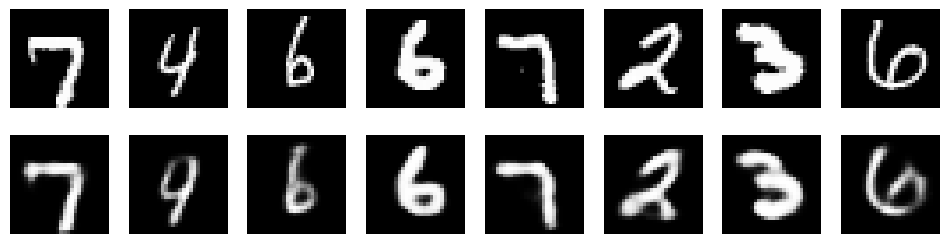

In [57]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)

    x_recon, _, _ = model(x)

    x = x.cpu()
    x_recon = x_recon.cpu()

    n = 8
    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].view(28, 28), cmap="gray")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recon[i].view(28, 28), cmap="gray")
        plt.axis("off")

    plt.show()

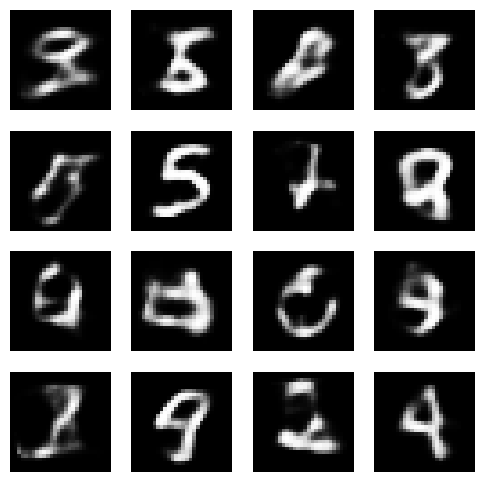

In [58]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decode(z).cpu()

    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(samples[i].view(28, 28), cmap="gray")
        plt.axis("off")
    plt.show()